In [2]:
import sys
print(sys.executable)

c:\Users\allan\anaconda3\envs\foresight\python.exe


In [4]:
import sys
print(sys.executable)

c:\Users\allan\anaconda3\envs\foresight\python.exe


In [6]:
import pandas as pd
print("Pandas version:", pd.__version__)


ModuleNotFoundError: No module named 'pandas'

In [4]:
import sys
print(sys.executable)

c:\Users\allan\anaconda3\envs\foresight\python.exe


In [5]:
import pandas as pd

print("Pandas works!")
print("Pandas version:", pd.__version__)

Pandas works!
Pandas version: 3.0.6


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
sales = pd.read_csv("../data/raw/sales_daily.csv")
sku_master = pd.read_csv("../data/raw/sku_master.csv")
calendar = pd.read_csv("../data/raw/calendar.csv")
inventory = pd.read_csv("../data/raw/inventory_snapshots.csv")

# Convert date columns
sales["date"] = pd.to_datetime(sales["date"])
sku_master["launch_date"] = pd.to_datetime(sku_master["launch_date"])
calendar["date"] = pd.to_datetime(calendar["date"])
inventory["date"] = pd.to_datetime(inventory["date"])

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [7]:
print("SALES DAILY:", sales.shape)
print("SKU MASTER:", sku_master.shape)
print("CALENDAR:", calendar.shape)
print("INVENTORY:", inventory.shape)

SALES DAILY: (54261, 6)
SKU MASTER: (100, 6)
CALENDAR: (731, 9)
INVENTORY: (10400, 6)


In [8]:
sales.head()

,date,sku_id,units_sold,revenue,unit_price,promo_flag
0,2024-09-27,SKU001,8,87325.76,10915.72,0
1,2024-09-28,SKU001,8,87325.76,10915.72,0
2,2024-09-29,SKU001,7,76410.04,10915.72,0
3,2024-09-30,SKU001,7,76410.04,10915.72,0
4,2024-10-01,SKU001,6,65494.32,10915.72,0


In [9]:
calendar.head()

,date,week,month,year,day_of_week,season,is_holiday,promo_event,promo_flag
0,2024-01-01,1,1,2024,0,Winter,0,No Promotion,0
1,2024-01-02,1,1,2024,1,Winter,0,No Promotion,0
2,2024-01-03,1,1,2024,2,Winter,0,No Promotion,0
3,2024-01-04,1,1,2024,3,Winter,0,No Promotion,0
4,2024-01-05,1,1,2024,4,Winter,0,No Promotion,0


In [10]:
inventory.head()

,date,sku_id,on_hand_units,on_order_units,lead_time_days,reorder_point
0,2024-01-07,SKU001,45,0,3,36
1,2024-01-14,SKU001,226,0,3,36
2,2024-01-21,SKU001,163,0,3,36
3,2024-01-28,SKU001,95,0,3,36
4,2024-02-04,SKU001,25,108,3,36


In [11]:
# ==============================
# BUSINESS KPIs
# ==============================

total_units = sales["units_sold"].sum()
total_revenue = sales["revenue"].sum()
avg_unit_price = sales["unit_price"].mean()
unique_skus = sales["sku_id"].nunique()

sales_start = sales["date"].min()
sales_end = sales["date"].max()

daily_sales = sales.groupby("date").agg(
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum")
)

avg_daily_units = daily_sales["units_sold"].mean()
avg_daily_revenue = daily_sales["revenue"].mean()

print("PROJECT FORESIGHT - BUSINESS KPIs")
print("=" * 50)

print(f"Total units sold:       {total_units:,}")
print(f"Total revenue:          ₹{total_revenue:,.2f}")
print(f"Average unit price:     ₹{avg_unit_price:,.2f}")
print(f"Unique SKUs:            {unique_skus}")
print(f"Sales start date:       {sales_start.date()}")
print(f"Sales end date:         {sales_end.date()}")
print(f"Average daily units:    {avg_daily_units:,.2f}")
print(f"Average daily revenue:  ₹{avg_daily_revenue:,.2f}")

PROJECT FORESIGHT - BUSINESS KPIs
Total units sold:       559,249
Total revenue:          ₹3,831,913,303.09
Average unit price:     ₹7,112.65
Unique SKUs:            100
Sales start date:       2024-01-04
Sales end date:         2025-12-31
Average daily units:    768.20
Average daily revenue:  ₹5,263,617.17


In [12]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Units Sold",
        "Total Revenue",
        "Average Unit Price",
        "Unique SKUs",
        "Sales Start Date",
        "Sales End Date",
        "Average Daily Units",
        "Average Daily Revenue"
    ],
    "Value": [
        f"{total_units:,}",
        f"₹{total_revenue:,.2f}",
        f"₹{avg_unit_price:,.2f}",
        unique_skus,
        str(sales_start.date()),
        str(sales_end.date()),
        f"{avg_daily_units:,.2f}",
        f"₹{avg_daily_revenue:,.2f}"
    ]
})

kpi_summary

,Metric,Value
0,Total Units Sold,"559,249"
1,Total Revenue,"₹3,831,913,303.09"
2,Average Unit Price,"₹7,112.65"
3,Unique SKUs,100
4,Sales Start Date,2024-01-04
5,Sales End Date,2025-12-31
6,Average Daily Units,768.20
7,Average Daily Revenue,"₹5,263,617.17"


In [13]:
# ==========================================
# CATEGORY PERFORMANCE ANALYSIS
# ==========================================

# Merge sales data with SKU master
sales_category = sales.merge(
    sku_master[["sku_id", "category", "subcategory"]],
    on="sku_id",
    how="left"
)

# Category-level performance
category_performance = sales_category.groupby("category").agg(
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum"),
    average_unit_price=("unit_price", "mean"),
    unique_skus=("sku_id", "nunique")
).reset_index()

# Sort by revenue
category_performance = category_performance.sort_values(
    "total_revenue",
    ascending=False
)

category_performance

,category,total_units,total_revenue,average_unit_price,unique_skus
0,Bedding,156710,1.067382e+09,6963.378086,29
4,Kitchen,133008,8.346067e+08,6893.252887,16
1,Electronics,90285,7.565364e+08,8264.908342,19
3,Home Decor,96647,6.509834e+08,6659.111884,14
2,Furniture,82599,5.224047e+08,6761.490256,22


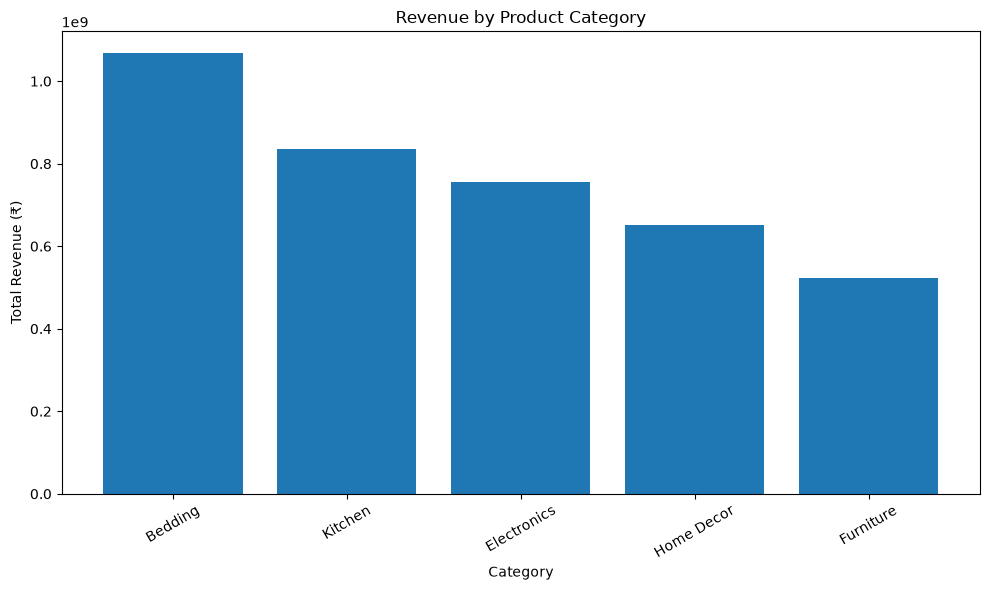

In [14]:
# ==========================================
# CATEGORY REVENUE CHART
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    category_performance["category"],
    category_performance["total_revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

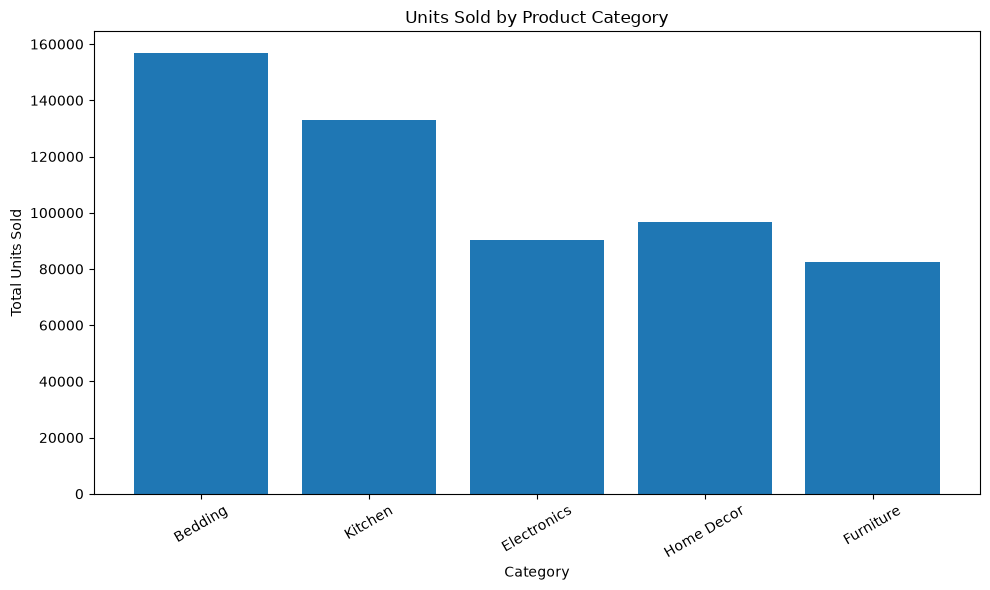

In [15]:
# ==========================================
# CATEGORY UNITS SOLD CHART
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    category_performance["category"],
    category_performance["total_units"]
)

plt.title("Units Sold by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

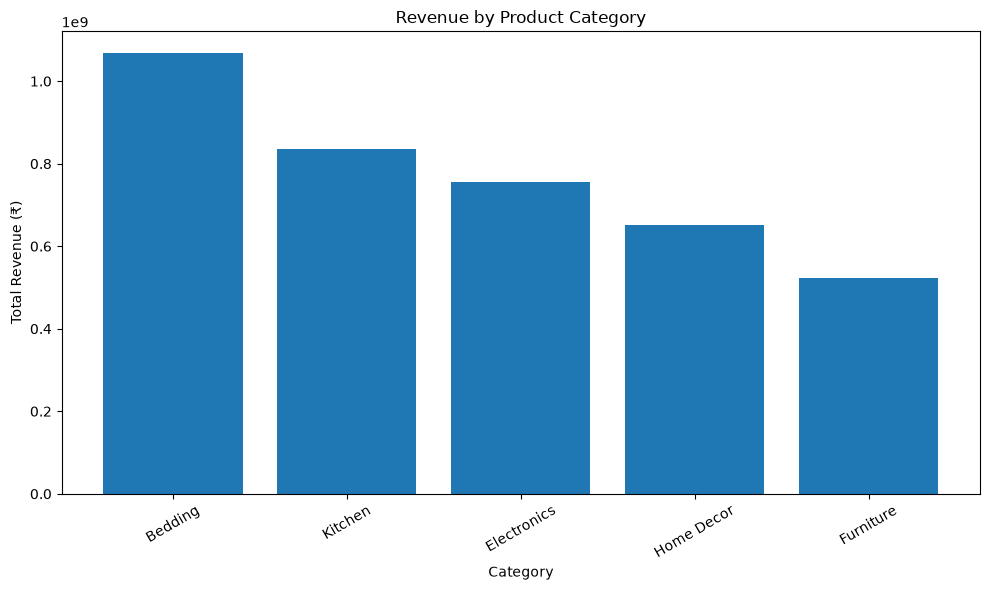

In [16]:
# ==========================================
# CATEGORY REVENUE CHART
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    category_performance["category"],
    category_performance["total_revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# OVERALL DAILY DEMAND TREND
# ==========================================

daily_demand = sales.groupby("date").agg(
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum")
).reset_index()

daily_demand.head()

,date,total_units,total_revenue
0,2024-01-04,10,108379.00
1,2024-01-05,26,246084.32
2,2024-01-06,24,221433.43
3,2024-01-07,42,407590.36
4,2024-01-08,18,168306.39


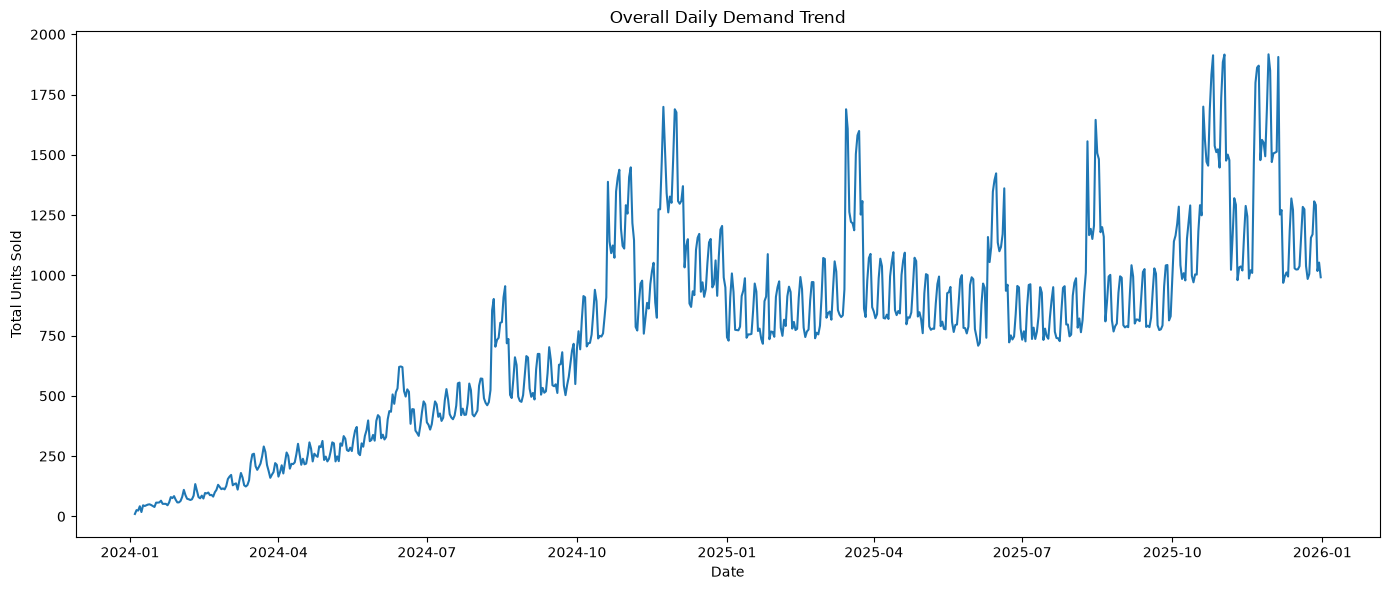

In [18]:
# ==========================================
# DAILY UNITS SOLD TREND
# ==========================================

plt.figure(figsize=(14, 6))

plt.plot(
    daily_demand["date"],
    daily_demand["total_units"]
)

plt.title("Overall Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()

In [19]:
# ==========================================
# DEMAND TREND SUMMARY
# ==========================================

print("Total days:", len(daily_demand))

print("Minimum daily units:",
      daily_demand["total_units"].min())

print("Maximum daily units:",
      daily_demand["total_units"].max())

print("Average daily units:",
      daily_demand["total_units"].mean())

print("Minimum revenue:",
      daily_demand["total_revenue"].min())

print("Maximum revenue:",
      daily_demand["total_revenue"].max())

print("Average daily revenue:",
      daily_demand["total_revenue"].mean())


Total days: 728
Minimum daily units: 10
Maximum daily units: 1917
Average daily units: 768.1991758241758
Minimum revenue: 108379.0
Maximum revenue: 12297937.65
Average daily revenue: 5263617.174574176


In [20]:
# ==========================================
# HIGHEST AND LOWEST DEMAND DAYS
# ==========================================

highest_demand = daily_demand.loc[
    daily_demand["total_units"].idxmax()
]

lowest_demand = daily_demand.loc[
    daily_demand["total_units"].idxmin()
]

print("Highest demand day:")
print(highest_demand)

print("\nLowest demand day:")
print(lowest_demand)

Highest demand day:
date             2025-11-29 00:00:00
total_units                     1917
total_revenue            12297937.65
Name: 695, dtype: object

Lowest demand day:
date             2024-01-04 00:00:00
total_units                       10
total_revenue               108379.0
Name: 0, dtype: object


In [21]:
# ==========================================
# MONTHLY DEMAND ANALYSIS
# ==========================================

sales["date"] = pd.to_datetime(sales["date"])

monthly_demand = sales.groupby(
    sales["date"].dt.to_period("M")
).agg(
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum")
).reset_index()

monthly_demand["date"] = monthly_demand["date"].dt.to_timestamp()

monthly_demand


,date,total_units,total_revenue
0,2024-01-01,1405,1.176421e+07
1,2024-02-01,2748,2.178138e+07
2,2024-03-01,5746,4.149434e+07
3,2024-04-01,7245,5.520490e+07
4,2024-05-01,9327,6.816329e+07
5,2024-06-01,13419,9.237094e+07
6,2024-07-01,13764,9.753515e+07
7,2024-08-01,19460,1.313013e+08
8,2024-09-01,17498,1.230922e+08
9,2024-10-01,29825,1.993268e+08


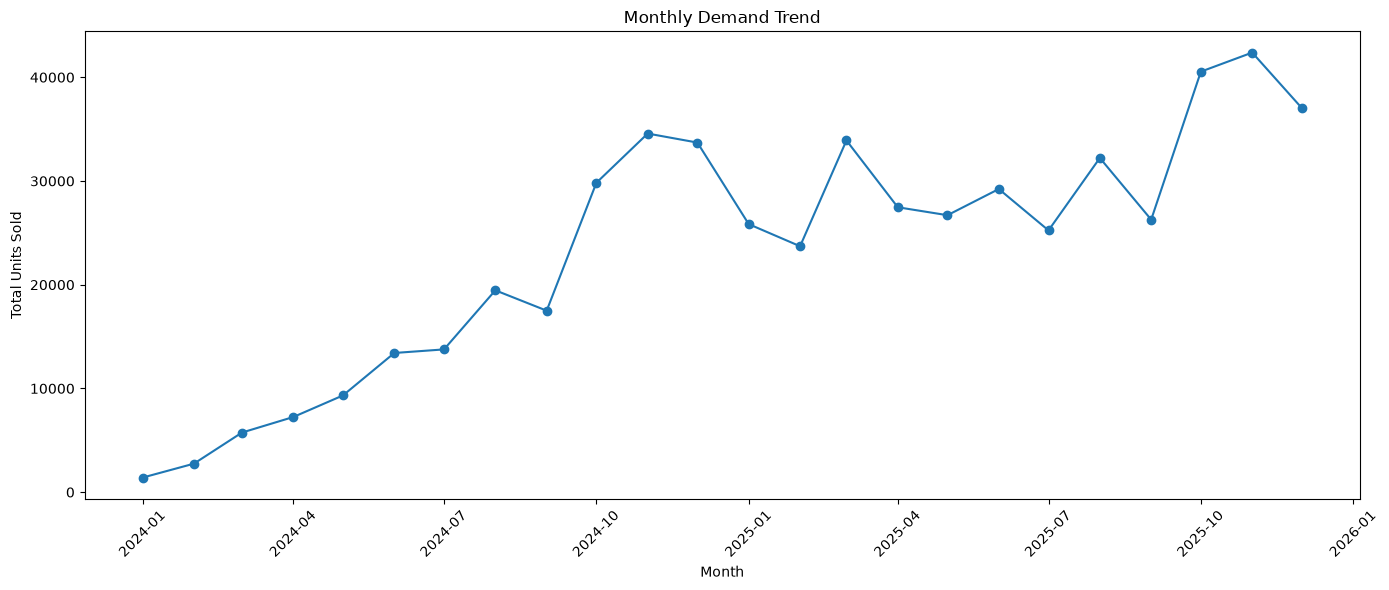

In [22]:
# ==========================================
# MONTHLY UNITS SOLD TREND
# ==========================================

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_demand["date"],
    monthly_demand["total_units"],
    marker="o"
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
# ==========================================
# HIGHEST AND LOWEST DEMAND MONTH
# ==========================================

highest_month = monthly_demand.loc[
    monthly_demand["total_units"].idxmax()
]

lowest_month = monthly_demand.loc[
    monthly_demand["total_units"].idxmin()
]

print("Highest demand month:")
print(highest_month)

print("\nLowest demand month:")
print(lowest_month)

Highest demand month:
date             2025-11-01 00:00:00
total_units                    42380
total_revenue           278530374.81
Name: 22, dtype: object

Lowest demand month:
date             2024-01-01 00:00:00
total_units                     1405
total_revenue            11764214.12
Name: 0, dtype: object


In [24]:
# ==========================================
# MONTHLY SEASONALITY ANALYSIS
# ==========================================

monthly_seasonality = sales.groupby(
    sales["date"].dt.month
).agg(
    average_units=("units_sold", "sum")
).reset_index()

monthly_seasonality["month_name"] = monthly_seasonality["date"].map({
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
})

monthly_seasonality

,date,average_units,month_name
0,1,27245,January
1,2,26457,February
2,3,39656,March
3,4,34713,April
4,5,36029,May
5,6,42645,June
6,7,39001,July
7,8,51680,August
8,9,43772,September
9,10,70368,October


In [25]:
# ==========================================
# MONTHLY SEASONALITY ANALYSIS
# ==========================================

sales["year"] = sales["date"].dt.year
sales["month"] = sales["date"].dt.month

monthly_seasonality = sales.groupby(
    ["year", "month"]
).agg(
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum")
).reset_index()

monthly_seasonality["month_name"] = monthly_seasonality["month"].map({
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
})

monthly_seasonality

,year,month,total_units,total_revenue,month_name
0,2024,1,1405,1.176421e+07,January
1,2024,2,2748,2.178138e+07,February
2,2024,3,5746,4.149434e+07,March
3,2024,4,7245,5.520490e+07,April
4,2024,5,9327,6.816329e+07,May
5,2024,6,13419,9.237094e+07,June
6,2024,7,13764,9.753515e+07,July
7,2024,8,19460,1.313013e+08,August
8,2024,9,17498,1.230922e+08,September
9,2024,10,29825,1.993268e+08,October


In [26]:
# ==========================================
# AVERAGE DEMAND BY CALENDAR MONTH
# ==========================================

seasonality_summary = monthly_seasonality.groupby(
    ["month", "month_name"]
).agg(
    average_units=("total_units", "mean"),
    average_revenue=("total_revenue", "mean")
).reset_index()

seasonality_summary = seasonality_summary.sort_values("month")

seasonality_summary

,month,month_name,average_units,average_revenue
0,1,January,13622.5,9.625523e+07
1,2,February,13228.5,9.384423e+07
2,3,March,19828.0,1.342648e+08
3,4,April,17356.5,1.238336e+08
4,5,May,18014.5,1.277067e+08
5,6,June,21322.5,1.437532e+08
6,7,July,19500.5,1.371911e+08
7,8,August,25840.0,1.733624e+08
8,9,September,21886.0,1.533747e+08
9,10,October,35184.0,2.351992e+08


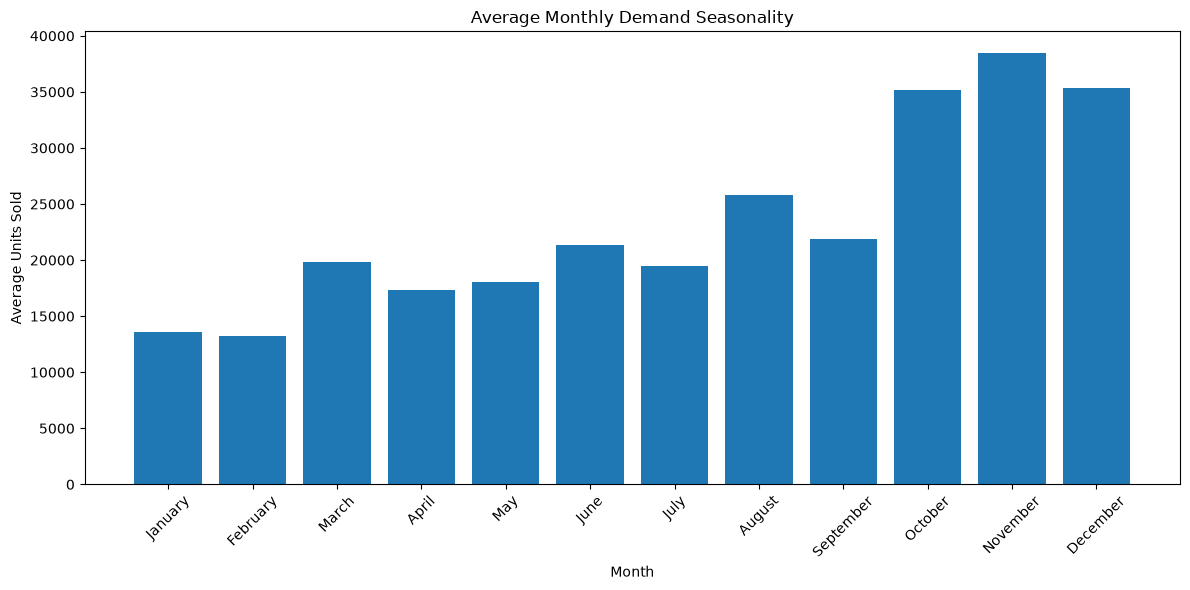

In [27]:
# ==========================================
# SEASONALITY VISUALIZATION
# ==========================================

plt.figure(figsize=(12, 6))

plt.bar(
    seasonality_summary["month_name"],
    seasonality_summary["average_units"]
)

plt.title("Average Monthly Demand Seasonality")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [28]:
# ==========================================
# YEAR-WISE MONTHLY DEMAND
# ==========================================

year_month_demand = monthly_seasonality.pivot(
    index="month_name",
    columns="year",
    values="total_units"
)

year_month_demand

year,2024,2025
month_name,,
April,7245,27468
August,19460,32220
December,33704,37025
February,2748,23709
January,1405,25840
July,13764,25237
June,13419,29226
March,5746,33910
May,9327,26702


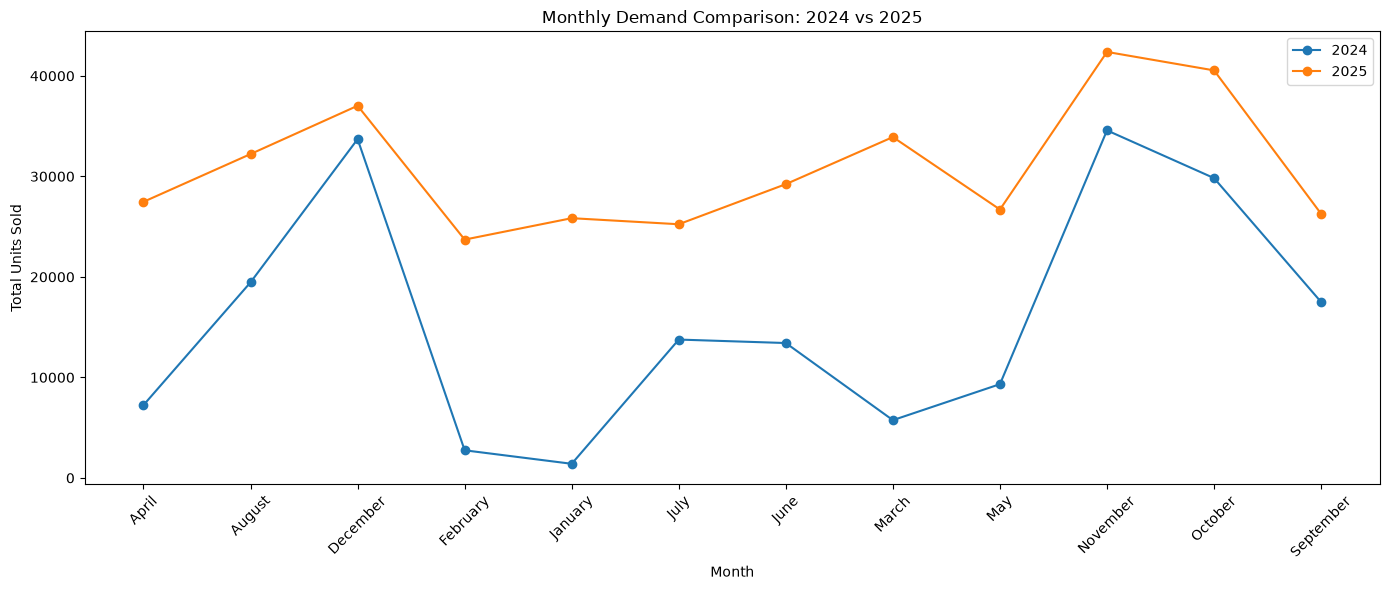

In [29]:
# ==========================================
# YEAR-WISE MONTHLY DEMAND COMPARISON
# ==========================================

plt.figure(figsize=(14, 6))

plt.plot(
    year_month_demand.index,
    year_month_demand[2024],
    marker="o",
    label="2024"
)

plt.plot(
    year_month_demand.index,
    year_month_demand[2025],
    marker="o",
    label="2025"
)

plt.title("Monthly Demand Comparison: 2024 vs 2025")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()
plt.show()

In [30]:
# ==========================================
# DEMAND VARIABILITY ANALYSIS
# ==========================================

demand_stats = daily_demand["total_units"].agg([
    "mean",
    "std",
    "min",
    "max"
])

demand_stats

mean     768.199176
std      415.994700
min       10.000000
max     1917.000000
Name: total_units, dtype: float64

In [31]:
# ==========================================
# COEFFICIENT OF VARIATION
# ==========================================

mean_demand = daily_demand["total_units"].mean()
std_demand = daily_demand["total_units"].std()

coefficient_variation = (std_demand / mean_demand) * 100

print("Average daily demand:", round(mean_demand, 2))
print("Demand standard deviation:", round(std_demand, 2))
print("Coefficient of variation:", round(coefficient_variation, 2), "%")

Average daily demand: 768.2
Demand standard deviation: 415.99
Coefficient of variation: 54.15 %


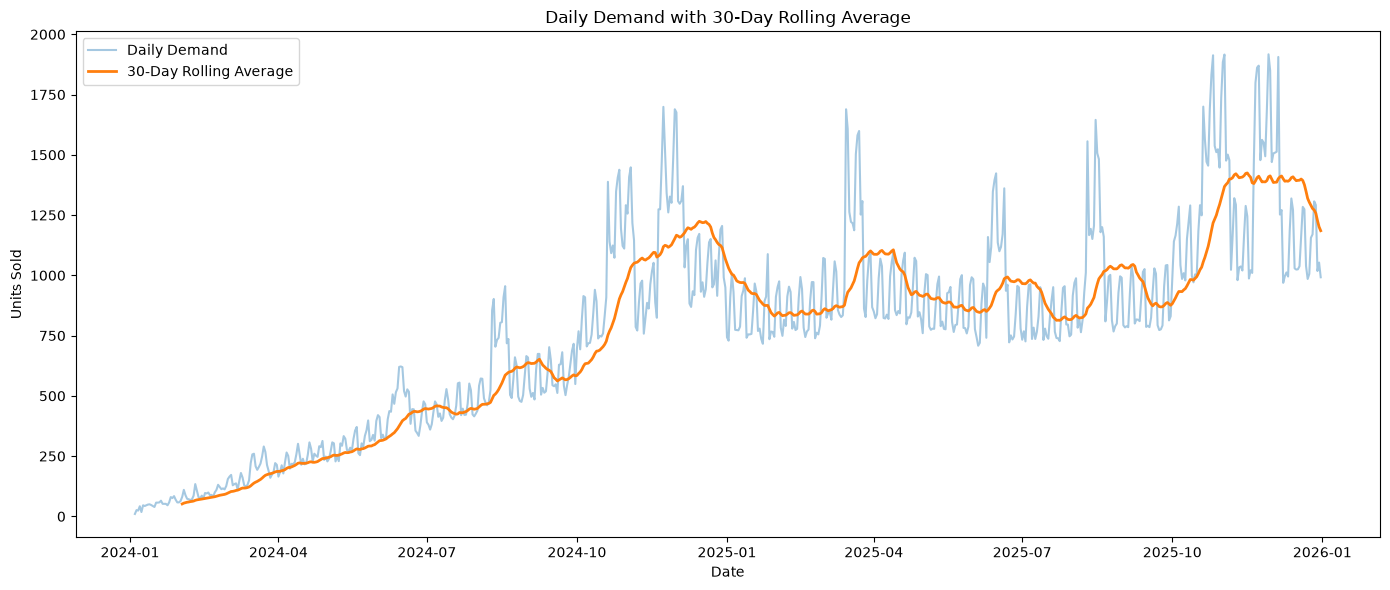

In [32]:
# ==========================================
# 30-DAY ROLLING AVERAGE
# ==========================================

daily_demand["rolling_30_day"] = (
    daily_demand["total_units"]
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_demand["date"],
    daily_demand["total_units"],
    alpha=0.4,
    label="Daily Demand"
)

plt.plot(
    daily_demand["date"],
    daily_demand["rolling_30_day"],
    linewidth=2,
    label="30-Day Rolling Average"
)

plt.title("Daily Demand with 30-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.legend()

plt.tight_layout()
plt.show()

In [33]:
# ==========================================
# 30-DAY ROLLING AVERAGE SUMMARY
# ==========================================

rolling_summary = daily_demand[
    ["date", "total_units", "rolling_30_day"]
].dropna()

print("First 5 rolling-average values:")
print(rolling_summary.head())

print("\nLast 5 rolling-average values:")
print(rolling_summary.tail())

print("\nMinimum 30-day rolling average:",
      round(rolling_summary["rolling_30_day"].min(), 2))

print("Maximum 30-day rolling average:",
      round(rolling_summary["rolling_30_day"].max(), 2))

First 5 rolling-average values:
         date  total_units  rolling_30_day
29 2024-02-02           81       51.666667
30 2024-02-03          110       55.000000
31 2024-02-04           88       57.066667
32 2024-02-05           73       58.700000
33 2024-02-06           71       59.666667

Last 5 rolling-average values:
          date  total_units  rolling_30_day
723 2025-12-27         1307     1270.866667
724 2025-12-28         1292     1257.633333
725 2025-12-29         1018     1227.666667
726 2025-12-30         1053     1201.100000
727 2025-12-31          992     1185.166667

Minimum 30-day rolling average: 51.67
Maximum 30-day rolling average: 1424.77


In [35]:
print(sales.columns.tolist())

['date', 'sku_id', 'units_sold', 'revenue', 'unit_price', 'promo_flag', 'year', 'month']


In [36]:
# ==========================================
# SKU-LEVEL DEMAND ANALYSIS
# ==========================================

sku_demand = sales.groupby("sku_id").agg(
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum")
).reset_index()

# Top 10 SKUs by units sold
top_skus_units = sku_demand.sort_values(
    "total_units",
    ascending=False
)

print("Top 10 SKUs by Units Sold:")
print(top_skus_units.head(10).to_string(index=False))

# Top 10 SKUs by revenue
top_skus_revenue = sku_demand.sort_values(
    "total_revenue",
    ascending=False
)

print("\nTop 10 SKUs by Revenue:")
print(top_skus_revenue.head(10).to_string(index=False))

Top 10 SKUs by Units Sold:
sku_id  total_units  total_revenue
SKU020        15189   171652261.74
SKU050        14433    66363774.66
SKU040        12796    92861662.21
SKU017        12300   124968825.97
SKU045        12096    48614153.33
SKU077        11990    13927448.13
SKU090        11494    76688710.12
SKU027        11171    87513495.31
SKU082        10978     6164571.77
SKU074        10879    83299578.63

Top 10 SKUs by Revenue:
sku_id  total_units  total_revenue
SKU020        15189   171652261.74
SKU017        12300   124968825.97
SKU089         8513   113333598.65
SKU088        10708   112942803.16
SKU040        12796    92861662.21
SKU062         5534    90069211.90
SKU084         7255    88224056.32
SKU027        11171    87513495.31
SKU060         6352    84869044.19
SKU021         7728    84613384.28


In [38]:
print(sales.columns.tolist())

sku_demand = sales.groupby("sku_id").agg(
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum")
).reset_index()

print("\nTop 10 SKUs by Units Sold:")
print(
    sku_demand.sort_values(
        "total_units",
        ascending=False
    ).head(10).to_string(index=False)
)

print("\nTop 10 SKUs by Revenue:")
print(
    sku_demand.sort_values(
        "total_revenue",
        ascending=False
    ).head(10).to_string(index=False)
)


['date', 'sku_id', 'units_sold', 'revenue', 'unit_price', 'promo_flag', 'year', 'month']

Top 10 SKUs by Units Sold:
sku_id  total_units  total_revenue
SKU020        15189   171652261.74
SKU050        14433    66363774.66
SKU040        12796    92861662.21
SKU017        12300   124968825.97
SKU045        12096    48614153.33
SKU077        11990    13927448.13
SKU090        11494    76688710.12
SKU027        11171    87513495.31
SKU082        10978     6164571.77
SKU074        10879    83299578.63

Top 10 SKUs by Revenue:
sku_id  total_units  total_revenue
SKU020        15189   171652261.74
SKU017        12300   124968825.97
SKU089         8513   113333598.65
SKU088        10708   112942803.16
SKU040        12796    92861662.21
SKU062         5534    90069211.90
SKU084         7255    88224056.32
SKU027        11171    87513495.31
SKU060         6352    84869044.19
SKU021         7728    84613384.28


In [39]:
# ==========================================
# UNIT PRICE ANALYSIS
# ==========================================

price_summary = sales["unit_price"].describe()

print("Unit Price Statistics:")
print(price_summary)

print("\nMinimum Unit Price:",
      round(sales["unit_price"].min(), 2))

print("Maximum Unit Price:",
      round(sales["unit_price"].max(), 2))

print("Average Unit Price:",
      round(sales["unit_price"].mean(), 2))

print("Median Unit Price:",
      round(sales["unit_price"].median(), 2))

Unit Price Statistics:
count    54261.000000
mean      7112.650737
std       3950.608950
min        490.800000
25%       4077.250000
50%       7038.710000
75%      10291.500000
max      16781.600000
Name: unit_price, dtype: float64

Minimum Unit Price: 490.8
Maximum Unit Price: 16781.6
Average Unit Price: 7112.65
Median Unit Price: 7038.71


In [40]:
# ==========================================
# PRICE VS UNITS SOLD
# ==========================================

price_units_corr = sales["unit_price"].corr(
    sales["units_sold"]
)

print("Correlation between Unit Price and Units Sold:",
      round(price_units_corr, 4))

Correlation between Unit Price and Units Sold: -0.1079


In [41]:
# ==========================================
# PROMOTION VS DEMAND ANALYSIS
# ==========================================

promo_analysis = sales.groupby("promo_flag").agg(
    total_units=("units_sold", "sum"),
    average_units=("units_sold", "mean"),
    total_revenue=("revenue", "sum"),
    average_revenue=("revenue", "mean")
).reset_index()

print("Promotion vs Non-Promotion Analysis:")
print(promo_analysis.to_string(index=False))

Promotion vs Non-Promotion Analysis:
 promo_flag  total_units  average_units  total_revenue  average_revenue
          0       400731       9.211360   2.824738e+09     64930.530816
          1       158518      14.736265   1.007175e+09     93629.775075


In [42]:
# ==========================================
# SKU PERFORMANCE ANALYSIS
# ==========================================

sku_performance = sales.groupby("sku_id").agg(
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum"),
    average_unit_price=("unit_price", "mean"),
    promotion_rate=("promo_flag", "mean")
).reset_index()

# Sort by revenue
sku_performance = sku_performance.sort_values(
    "total_revenue",
    ascending=False
)

print("Top 10 SKUs by Revenue:")
print(sku_performance.head(10).to_string(index=False))

Top 10 SKUs by Revenue:
sku_id  total_units  total_revenue  average_unit_price  promotion_rate
SKU020        15189   171652261.74        11399.205346        0.193548
SKU017        12300   124968825.97        10245.419440        0.194404
SKU089         8513   113333598.65        13422.785734        0.211538
SKU088        10708   112942803.16        10635.945179        0.181319
SKU040        12796    92861662.21         7326.404934        0.200997
SKU062         5534    90069211.90        16426.290558        0.211628
SKU084         7255    88224056.32        12257.852160        0.214008
SKU027        11171    87513495.31         7906.598082        0.190252
SKU060         6352    84869044.19        13459.988392        0.184615
SKU021         7728    84613384.28        11056.030160        0.203593


In [43]:
# ==========================================
# SKU REVENUE CONCENTRATION
# ==========================================

sku_concentration = sku_performance.copy()

# Calculate cumulative revenue
sku_concentration["cumulative_revenue"] = (
    sku_concentration["total_revenue"].cumsum()
)

# Calculate cumulative revenue percentage
total_revenue = sku_concentration["total_revenue"].sum()

sku_concentration["cumulative_revenue_pct"] = (
    sku_concentration["cumulative_revenue"] / total_revenue * 100
)

print("SKU Revenue Concentration:")
print(
    sku_concentration[
        ["sku_id", "total_revenue", "cumulative_revenue_pct"]
    ].head(20).to_string(index=False)
)

SKU Revenue Concentration:
sku_id  total_revenue  cumulative_revenue_pct
SKU020   171652261.74                4.479545
SKU017   124968825.97                7.740809
SKU089   113333598.65               10.698433
SKU088   112942803.16               13.645859
SKU040    92861662.21               16.069235
SKU062    90069211.90               18.419737
SKU084    88224056.32               20.722087
SKU027    87513495.31               23.005894
SKU060    84869044.19               25.220690
SKU021    84613384.28               27.428813
SKU074    83299578.63               29.602651
SKU087    77636939.68               31.628713
SKU090    76688710.12               33.630029
SKU023    75002849.10               35.587351
SKU099    71288398.20               37.447737
SKU086    68606585.25               39.238137
SKU051    68523701.35               41.026375
SKU050    66363774.66               42.758245
SKU008    63226065.85               44.408232
SKU019    62913694.21               46.050067


In [44]:
# ==========================================
# LOWEST PERFORMING SKUs
# ==========================================

lowest_skus = sku_performance.sort_values(
    "total_revenue",
    ascending=True
).head(10)

print("Bottom 10 SKUs by Revenue:")
print(
    lowest_skus[
        [
            "sku_id",
            "total_units",
            "total_revenue",
            "average_unit_price",
            "promotion_rate"
        ]
    ].to_string(index=False)
)

Bottom 10 SKUs by Revenue:
sku_id  total_units  total_revenue  average_unit_price  promotion_rate
SKU055         3267     2431198.26          750.459930        0.211909
SKU004         3881     2519338.36          655.605731        0.226027
SKU012         2445     2832689.31         1170.337842        0.211538
SKU036         3148     3737324.03         1197.235945        0.195477
SKU092         3920     4397895.10         1133.390246        0.221477
SKU014         4618     5004065.70         1091.583270        0.196682
SKU032         3019     5066055.64         1692.338469        0.202952
SKU065         4608     5642098.46         1232.930269        0.177419
SKU072         1978     5729670.90         2919.878410        0.169231
SKU082        10978     6164571.77          566.329969        0.187307


In [45]:

# ==========================================
# CHECK SKU MASTER COLUMNS
# ==========================================

print("SKU Master Columns:")
print(sku_master.columns.tolist())

print("\nFirst 5 rows:")
print(sku_master.head().to_string())

SKU Master Columns:
['sku_id', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price']

First 5 rows:
   sku_id    category          subcategory launch_date  unit_cost  list_price
0  SKU001     Bedding            Bedsheets  2024-09-27    5936.35    10915.72
1  SKU002  Home Decor             Wall Art  2024-08-02     747.24     1553.93
2  SKU003     Bedding  Mattress Protectors  2024-05-31    5311.84     7175.08
3  SKU004     Bedding              Pillows  2024-10-20     306.00      671.06
4  SKU005   Furniture               Chairs  2024-11-09    4340.62     7330.22


In [46]:
# ==========================================
# MERGE SALES DATA WITH SKU MASTER
# ==========================================

sales_enriched = sales.merge(
    sku_master,
    on="sku_id",
    how="left"
)

print("Enriched dataset shape:")
print(sales_enriched.shape)

print("\nEnriched dataset columns:")
print(sales_enriched.columns.tolist())

print("\nFirst 5 rows:")
print(sales_enriched.head().to_string())

Enriched dataset shape:
(54261, 13)

Enriched dataset columns:
['date', 'sku_id', 'units_sold', 'revenue', 'unit_price', 'promo_flag', 'year', 'month', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price']

First 5 rows:
        date  sku_id  units_sold   revenue  unit_price  promo_flag  year  month category subcategory launch_date  unit_cost  list_price
0 2024-09-27  SKU001           8  87325.76    10915.72           0  2024      9  Bedding   Bedsheets  2024-09-27    5936.35    10915.72
1 2024-09-28  SKU001           8  87325.76    10915.72           0  2024      9  Bedding   Bedsheets  2024-09-27    5936.35    10915.72
2 2024-09-29  SKU001           7  76410.04    10915.72           0  2024      9  Bedding   Bedsheets  2024-09-27    5936.35    10915.72
3 2024-09-30  SKU001           7  76410.04    10915.72           0  2024      9  Bedding   Bedsheets  2024-09-27    5936.35    10915.72
4 2024-10-01  SKU001           6  65494.32    10915.72           0  2024     10  Bed

In [47]:
# ==========================================
# PROFITABILITY ANALYSIS
# ==========================================

sales_enriched["total_cost"] = (
    sales_enriched["units_sold"] * sales_enriched["unit_cost"]
)

sales_enriched["profit"] = (
    sales_enriched["revenue"] - sales_enriched["total_cost"]
)

sales_enriched["profit_margin_pct"] = (
    sales_enriched["profit"] / sales_enriched["revenue"]
) * 100

# Overall profitability
total_revenue = sales_enriched["revenue"].sum()
total_cost = sales_enriched["total_cost"].sum()
total_profit = sales_enriched["profit"].sum()
overall_margin = (total_profit / total_revenue) * 100

print("Overall Profitability:")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Cost: ₹{total_cost:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Overall Profit Margin: {overall_margin:.2f}%")

Overall Profitability:
Total Revenue: ₹3,831,913,303.09
Total Cost: ₹2,202,547,994.11
Total Profit: ₹1,629,365,308.98
Overall Profit Margin: 42.52%


In [48]:
# ==========================================
# PROFITABILITY BY CATEGORY
# ==========================================

category_profit = sales_enriched.groupby("category").agg(
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum"),
    total_cost=("total_cost", "sum"),
    total_profit=("profit", "sum")
).reset_index()

category_profit["profit_margin_pct"] = (
    category_profit["total_profit"] /
    category_profit["total_revenue"]
) * 100

# Sort by profit
category_profit = category_profit.sort_values(
    "total_profit",
    ascending=False
)

print("Profitability by Category:")
print(
    category_profit.to_string(index=False)
)

Profitability by Category:
   category  total_units  total_revenue   total_cost  total_profit  profit_margin_pct
    Bedding       156710   1.067382e+09 625744990.67  441637026.04          41.375723
    Kitchen       133008   8.346067e+08 476175259.09  358431471.91          42.946152
Electronics        90285   7.565364e+08 410677526.07  345858901.72          45.716094
 Home Decor        96647   6.509834e+08 368726672.28  282256728.30          43.358514
  Furniture        82599   5.224047e+08 321223546.00  201181181.01          38.510597


In [49]:
# ==========================================
# PROFITABILITY BY SUBCATEGORY
# ==========================================

subcategory_profit = sales_enriched.groupby(
    ["category", "subcategory"]
).agg(
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum"),
    total_cost=("total_cost", "sum"),
    total_profit=("profit", "sum")
).reset_index()

subcategory_profit["profit_margin_pct"] = (
    subcategory_profit["total_profit"] /
    subcategory_profit["total_revenue"]
) * 100

subcategory_profit = subcategory_profit.sort_values(
    "total_profit",
    ascending=False
)

print("Profitability by Subcategory:")
print(
    subcategory_profit.to_string(index=False)
)

Profitability by Subcategory:
   category         subcategory  total_units  total_revenue   total_cost  total_profit  profit_margin_pct
    Bedding Mattress Protectors        45489   370856012.62 214145294.64  156710717.98          42.256486
    Kitchen          Appliances        45099   329925316.85 183113312.28  146812004.57          44.498557
    Bedding             Pillows        47768   321895516.94 177067363.07  144828153.87          44.992287
 Home Decor            Wall Art        43488   285843722.03 148794186.64  137049535.39          47.945617
Electronics      Smart Lighting        24228   247932145.50 120618834.40  127313311.10          51.350062
    Kitchen          Dinnerware        43362   252872140.14 145296808.50  107575331.64          42.541393
    Bedding           Bedsheets        36137   262152708.41 167055432.73   95097275.68          36.275527
  Furniture              Chairs        40559   227028647.36 139254802.64   87773844.72          38.662013
Electronics     

In [50]:
# ==========================================
# PROMOTION PERFORMANCE BY CATEGORY
# ==========================================

promo_category = sales_enriched.groupby(
    ["category", "promo_flag"]
).agg(
    total_units=("units_sold", "sum"),
    average_units=("units_sold", "mean"),
    total_revenue=("revenue", "sum"),
    average_revenue=("revenue", "mean")
).reset_index()

print("Promotion Performance by Category:")
print(
    promo_category.to_string(index=False)
)

Promotion Performance by Category:
   category  promo_flag  total_units  average_units  total_revenue  average_revenue
    Bedding           0       112106       9.161981   786717558.64     64295.321890
    Bedding           1        44604      14.619469   280664458.07     91990.972819
Electronics           0        64762       7.840436   557735286.99     67522.431839
Electronics           1        25523      12.511275   198801140.80     97451.539608
  Furniture           0        59316       6.200711   387863696.84     40546.069082
  Furniture           1        23283       9.853153   134541030.17     56936.534139
 Home Decor           0        69548      11.749958   479840785.91     81067.880708
 Home Decor           1        27099      18.792649   171142614.67    118684.198800
    Kitchen           0        94999      12.627808   612580484.23     81427.686326
    Kitchen           1        38009      20.423966   222026246.77    119304.807507


In [51]:
# ==========================================
# PROMOTION LIFT BY CATEGORY
# ==========================================

promo_lift = promo_category.pivot(
    index="category",
    columns="promo_flag",
    values="average_units"
).reset_index()

promo_lift.columns = [
    "category",
    "non_promo_avg_units",
    "promo_avg_units"
]

promo_lift["promotion_lift_pct"] = (
    (promo_lift["promo_avg_units"] -
     promo_lift["non_promo_avg_units"])
    / promo_lift["non_promo_avg_units"]
) * 100

promo_lift = promo_lift.sort_values(
    "promotion_lift_pct",
    ascending=False
)

print("Promotion Lift by Category:")
print(
    promo_lift.to_string(index=False)
)

Promotion Lift by Category:
   category  non_promo_avg_units  promo_avg_units  promotion_lift_pct
    Kitchen            12.627808        20.423966           61.738011
 Home Decor            11.749958        18.792649           59.938014
Electronics             7.840436        12.511275           59.573712
    Bedding             9.161981        14.619469           59.566681
  Furniture             6.200711         9.853153           58.903600


In [52]:
# ==========================================
# SKU PERFORMANCE SUMMARY
# ==========================================

sku_performance = sales_enriched.groupby(
    ["sku_id", "category", "subcategory"]
).agg(
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum"),
    total_cost=("total_cost", "sum"),
    total_profit=("profit", "sum")
).reset_index()

sku_performance["profit_margin_pct"] = (
    sku_performance["total_profit"] /
    sku_performance["total_revenue"]
) * 100

# Sort by total profit
sku_performance = sku_performance.sort_values(
    "total_profit",
    ascending=False
)

print("Top 15 SKUs by Profit:")
print(
    sku_performance.head(15).to_string(index=False)
)

Top 15 SKUs by Profit:
sku_id    category         subcategory  total_units  total_revenue  total_cost  total_profit  profit_margin_pct
SKU020     Kitchen          Appliances        15189   171652261.74 87751865.37   83900396.37          48.878119
SKU017  Home Decor            Wall Art        12300   124968825.97 59261154.00   65707671.97          52.579250
SKU088 Electronics      Smart Lighting        10708   112942803.16 53990271.40   58952531.76          52.196802
SKU089  Home Decor               Lamps         8513   113333598.65 64186062.01   49147536.64          43.365372
SKU062 Electronics      Smart Lighting         5534    90069211.90 42851090.16   47218121.74          52.424264
SKU021     Kitchen            Cookware         7728    84613384.28 41061105.12   43552279.16          51.472092
SKU084     Bedding Mattress Protectors         7255    88224056.32 44820737.05   43403319.27          49.196694
SKU074     Bedding Mattress Protectors        10879    83299578.63 41568006.26   

In [53]:
# ==========================================
# PRICE VS PROFIT MARGIN
# ==========================================

sku_price_margin = sales_enriched.groupby(
    ["sku_id", "category", "subcategory"]
).agg(
    average_unit_price=("unit_price", "mean"),
    total_revenue=("revenue", "sum"),
    total_profit=("profit", "sum")
).reset_index()

sku_price_margin["profit_margin_pct"] = (
    sku_price_margin["total_profit"] /
    sku_price_margin["total_revenue"]
) * 100

print("Price vs Profit Margin:")
print(
    sku_price_margin.sort_values(
        "average_unit_price",
        ascending=False
    ).head(15).to_string(index=False)
)

Price vs Profit Margin:
sku_id    category         subcategory  average_unit_price  total_revenue  total_profit  profit_margin_pct
SKU062 Electronics      Smart Lighting        16426.290558    90069211.90   47218121.74          52.424264
SKU024   Furniture              Tables        15750.620666    31537849.69   15817846.09          50.155119
SKU049   Furniture                Beds        13659.843388    23265331.58    9971049.71          42.857974
SKU048     Bedding Mattress Protectors        13642.393523    51109242.41   21419687.21          41.909616
SKU096     Bedding           Bedsheets        13597.363934    37702673.81   16009388.18          42.462209
SKU060   Furniture              Chairs        13459.988392    84869044.19   34319574.11          40.438271
SKU089  Home Decor               Lamps        13422.785734   113333598.65   49147536.64          43.365372
SKU068  Home Decor            Wall Art        13347.990156    50148474.79   25369947.49          50.589669
SKU008     Ki

In [54]:
# ==========================================
# PRODUCT AGE / LAUNCH PERFORMANCE
# ==========================================

sku_launch = sales_enriched.groupby(
    ["sku_id", "category", "subcategory", "launch_date"]
).agg(
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum"),
    total_profit=("profit", "sum")
).reset_index()

# Calculate number of days the product has been available
sku_launch["days_since_launch"] = (
    sales_enriched["date"].max() -
    sku_launch["launch_date"]
).dt.days

print("Product Launch Performance:")
print(
    sku_launch.sort_values(
        "total_units",
        ascending=False
    ).head(15).to_string(index=False)
)

Product Launch Performance:
sku_id    category         subcategory launch_date  total_units  total_revenue  total_profit  days_since_launch
SKU020     Kitchen          Appliances  2024-03-21        15189   171652261.74   83900396.37                650
SKU050     Kitchen          Appliances  2024-01-09        14433    66363774.66   31041749.43                722
SKU040     Kitchen             Storage  2024-05-09        12796    92861662.21   36710255.01                601
SKU017  Home Decor            Wall Art  2024-02-22        12300   124968825.97   65707671.97                678
SKU045     Kitchen          Appliances  2024-05-26        12096    48614153.33   12510859.25                584
SKU077     Kitchen          Dinnerware  2024-02-27        11990    13927448.13    3087169.23                673
SKU090  Home Decor            Wall Art  2024-02-02        11494    76688710.12   32683356.42                698
SKU027     Bedding           Bedsheets  2024-04-05        11171    87513495.

In [55]:
# ==========================================
# CREATE MODELING DATASET
# ==========================================

model_data = sales_enriched.copy()

print("Modeling dataset shape:")
print(model_data.shape)

print("\nColumns:")
print(model_data.columns.tolist())

print("\nMissing values:")
print(model_data.isnull().sum())

Modeling dataset shape:
(54261, 16)

Columns:
['date', 'sku_id', 'units_sold', 'revenue', 'unit_price', 'promo_flag', 'year', 'month', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price', 'total_cost', 'profit', 'profit_margin_pct']

Missing values:
date                 0
sku_id               0
units_sold           0
revenue              0
unit_price           0
promo_flag           0
year                 0
month                0
category             0
subcategory          0
launch_date          0
unit_cost            0
list_price           0
total_cost           0
profit               0
profit_margin_pct    0
dtype: int64


In [56]:
# ==========================================
# STEP 1: TIME-BASED FEATURES
# ==========================================

model_data["day_of_week"] = model_data["date"].dt.dayofweek
model_data["day_of_month"] = model_data["date"].dt.day
model_data["week_of_year"] = model_data["date"].dt.isocalendar().week.astype(int)
model_data["quarter"] = model_data["date"].dt.quarter

# Weekend indicator
model_data["is_weekend"] = (
    model_data["day_of_week"] >= 5
).astype(int)

print("Time features created successfully.")

print("\nNew columns:")
print([
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "quarter",
    "is_weekend"
])

print("\nSample:")
print(
    model_data[
        [
            "date",
            "day_of_week",
            "day_of_month",
            "week_of_year",
            "quarter",
            "is_weekend"
        ]
    ].head(10).to_string(index=False)
)

Time features created successfully.

New columns:
['day_of_week', 'day_of_month', 'week_of_year', 'quarter', 'is_weekend']

Sample:
      date  day_of_week  day_of_month  week_of_year  quarter  is_weekend
2024-09-27            4            27            39        3           0
2024-09-28            5            28            39        3           1
2024-09-29            6            29            39        3           1
2024-09-30            0            30            40        3           0
2024-10-01            1             1            40        4           0
2024-10-02            2             2            40        4           0
2024-10-03            3             3            40        4           0
2024-10-04            4             4            40        4           0
2024-10-05            5             5            40        4           1
2024-10-06            6             6            40        4           1


In [57]:
# ==========================================
# STEP 2: PRODUCT AGE FEATURE
# ==========================================

model_data["product_age_days"] = (
    model_data["date"] - model_data["launch_date"]
).dt.days

print("Product age feature created successfully.")

print("\nProduct age statistics:")
print(
    model_data["product_age_days"].describe()
)

print("\nSample:")
print(
    model_data[
        [
            "sku_id",
            "date",
            "launch_date",
            "product_age_days"
        ]
    ].head(10).to_string(index=False)
)

Product age feature created successfully.

Product age statistics:
count    54261.000000
mean       280.573709
std        172.527151
min          0.000000
25%        135.000000
50%        271.000000
75%        408.000000
max        727.000000
Name: product_age_days, dtype: float64

Sample:
sku_id       date launch_date  product_age_days
SKU001 2024-09-27  2024-09-27                 0
SKU001 2024-09-28  2024-09-27                 1
SKU001 2024-09-29  2024-09-27                 2
SKU001 2024-09-30  2024-09-27                 3
SKU001 2024-10-01  2024-09-27                 4
SKU001 2024-10-02  2024-09-27                 5
SKU001 2024-10-03  2024-09-27                 6
SKU001 2024-10-04  2024-09-27                 7
SKU001 2024-10-05  2024-09-27                 8
SKU001 2024-10-06  2024-09-27                 9


In [58]:
# ==========================================
# STEP 3: LAG FEATURES
# ==========================================

# Make sure data is sorted correctly
model_data = model_data.sort_values(
    ["sku_id", "date"]
).reset_index(drop=True)

# Previous demand for each SKU
model_data["lag_1"] = (
    model_data.groupby("sku_id")["units_sold"]
    .shift(1)
)

model_data["lag_7"] = (
    model_data.groupby("sku_id")["units_sold"]
    .shift(7)
)

model_data["lag_30"] = (
    model_data.groupby("sku_id")["units_sold"]
    .shift(30)
)

print("Lag features created successfully.")

print("\nLag columns:")
print([
    "lag_1",
    "lag_7",
    "lag_30"
])

print("\nSample:")
print(
    model_data[
        [
            "sku_id",
            "date",
            "units_sold",
            "lag_1",
            "lag_7",
            "lag_30"
        ]
    ].head(40).to_string(index=False)
)

Lag features created successfully.

Lag columns:
['lag_1', 'lag_7', 'lag_30']

Sample:
sku_id       date  units_sold  lag_1  lag_7  lag_30
SKU001 2024-09-27           8    NaN    NaN     NaN
SKU001 2024-09-28           8    8.0    NaN     NaN
SKU001 2024-09-29           7    8.0    NaN     NaN
SKU001 2024-09-30           7    7.0    NaN     NaN
SKU001 2024-10-01           6    7.0    NaN     NaN
SKU001 2024-10-02          10    6.0    NaN     NaN
SKU001 2024-10-03          12   10.0    NaN     NaN
SKU001 2024-10-04          11   12.0    8.0     NaN
SKU001 2024-10-05          11   11.0    8.0     NaN
SKU001 2024-10-06          11   11.0    7.0     NaN
SKU001 2024-10-07           8   11.0    7.0     NaN
SKU001 2024-10-08           6    8.0    6.0     NaN
SKU001 2024-10-09           6    6.0   10.0     NaN
SKU001 2024-10-10           9    6.0   12.0     NaN
SKU001 2024-10-11           9    9.0   11.0     NaN
SKU001 2024-10-12          12    9.0   11.0     NaN
SKU001 2024-10-13          14

In [59]:
print(model_data[["sku_id", "date", "units_sold", "lag_1", "lag_7", "lag_30"]].head(15))

    sku_id       date  units_sold  lag_1  lag_7  lag_30
0   SKU001 2024-09-27           8    NaN    NaN     NaN
1   SKU001 2024-09-28           8    8.0    NaN     NaN
2   SKU001 2024-09-29           7    8.0    NaN     NaN
3   SKU001 2024-09-30           7    7.0    NaN     NaN
4   SKU001 2024-10-01           6    7.0    NaN     NaN
5   SKU001 2024-10-02          10    6.0    NaN     NaN
6   SKU001 2024-10-03          12   10.0    NaN     NaN
7   SKU001 2024-10-04          11   12.0    8.0     NaN
8   SKU001 2024-10-05          11   11.0    8.0     NaN
9   SKU001 2024-10-06          11   11.0    7.0     NaN
10  SKU001 2024-10-07           8   11.0    7.0     NaN
11  SKU001 2024-10-08           6    8.0    6.0     NaN
12  SKU001 2024-10-09           6    6.0   10.0     NaN
13  SKU001 2024-10-10           9    6.0   12.0     NaN
14  SKU001 2024-10-11           9    9.0   11.0     NaN


In [60]:
print(model_data[["lag_1", "lag_7", "lag_30"]].isna().sum())

lag_1      100
lag_7      700
lag_30    3000
dtype: int64


In [61]:
# ==========================================
# STEP 4: ROLLING DEMAND FEATURES
# ==========================================

# 7-record rolling average
model_data["rolling_mean_7"] = (
    model_data.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

# 30-record rolling average
model_data["rolling_mean_30"] = (
    model_data.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(30).mean())
)

# 7-record rolling standard deviation
model_data["rolling_std_7"] = (
    model_data.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

print("Rolling features created successfully.")

print("\nRolling feature columns:")
print([
    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7"
])

print("\nSample:")
print(
    model_data[
        [
            "sku_id",
            "date",
            "units_sold",
            "rolling_mean_7",
            "rolling_mean_30",
            "rolling_std_7"
        ]
    ].head(40).to_string(index=False)
)

Rolling features created successfully.

Rolling feature columns:
['rolling_mean_7', 'rolling_mean_30', 'rolling_std_7']

Sample:
sku_id       date  units_sold  rolling_mean_7  rolling_mean_30  rolling_std_7
SKU001 2024-09-27           8             NaN              NaN            NaN
SKU001 2024-09-28           8             NaN              NaN            NaN
SKU001 2024-09-29           7             NaN              NaN            NaN
SKU001 2024-09-30           7             NaN              NaN            NaN
SKU001 2024-10-01           6             NaN              NaN            NaN
SKU001 2024-10-02          10             NaN              NaN            NaN
SKU001 2024-10-03          12             NaN              NaN            NaN
SKU001 2024-10-04          11        8.285714              NaN       2.058663
SKU001 2024-10-05          11        8.714286              NaN       2.288689
SKU001 2024-10-06          11        9.142857              NaN       2.410295
SKU001 2024-1

In [62]:
# ==========================================
# STEP 5: PRICE & PROMOTION FEATURES
# ==========================================

# Price difference from the normal/list price
model_data["price_difference"] = (
    model_data["list_price"] - model_data["unit_price"]
)

# Percentage discount from list price
model_data["discount_pct"] = (
    (model_data["list_price"] - model_data["unit_price"])
    / model_data["list_price"]
) * 100

# Promotion and discount interaction
model_data["promo_discount"] = (
    model_data["promo_flag"] * model_data["discount_pct"]
)

print("Price and promotion features created successfully.")

print("\nNew feature columns:")
print([
    "price_difference",
    "discount_pct",
    "promo_discount"
])

print("\nSample:")
print(
    model_data[
        [
            "sku_id",
            "date",
            "unit_price",
            "list_price",
            "promo_flag",
            "price_difference",
            "discount_pct",
            "promo_discount"
        ]
    ].head(15).to_string(index=False)
)

Price and promotion features created successfully.

New feature columns:
['price_difference', 'discount_pct', 'promo_discount']

Sample:
sku_id       date  unit_price  list_price  promo_flag  price_difference  discount_pct  promo_discount
SKU001 2024-09-27    10915.72    10915.72           0               0.0           0.0             0.0
SKU001 2024-09-28    10915.72    10915.72           0               0.0           0.0             0.0
SKU001 2024-09-29    10915.72    10915.72           0               0.0           0.0             0.0
SKU001 2024-09-30    10915.72    10915.72           0               0.0           0.0             0.0
SKU001 2024-10-01    10915.72    10915.72           0               0.0           0.0             0.0
SKU001 2024-10-02    10915.72    10915.72           0               0.0           0.0             0.0
SKU001 2024-10-03    10915.72    10915.72           0               0.0           0.0             0.0
SKU001 2024-10-04    10915.72    10915.72      

In [63]:
# ==========================================
# STEP 6: CHECK MODEL DATASET
# ==========================================

print("Model data shape:")
print(model_data.shape)

print("\nAll columns:")
print(model_data.columns.tolist())

print("\nMissing values:")
print(model_data.isna().sum())

print("\nData types:")
print(model_data.dtypes)

Model data shape:
(54261, 31)

All columns:
['date', 'sku_id', 'units_sold', 'revenue', 'unit_price', 'promo_flag', 'year', 'month', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price', 'total_cost', 'profit', 'profit_margin_pct', 'day_of_week', 'day_of_month', 'week_of_year', 'quarter', 'is_weekend', 'product_age_days', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'price_difference', 'discount_pct', 'promo_discount']

Missing values:
date                    0
sku_id                  0
units_sold              0
revenue                 0
unit_price              0
promo_flag              0
year                    0
month                   0
category                0
subcategory             0
launch_date             0
unit_cost               0
list_price              0
total_cost              0
profit                  0
profit_margin_pct       0
day_of_week             0
day_of_month            0
week_of_year            0
quarter       

In [64]:
# ==========================================
# STEP 6A: CHECK FEATURE MISSING VALUES
# ==========================================

feature_columns = [
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7"
]

print("Missing values in lag and rolling features:")
print(model_data[feature_columns].isna().sum())

print("\nTotal rows:")
print(len(model_data))

print("\nRows with any missing lag/rolling value:")
print(model_data[feature_columns].isna().any(axis=1).sum())

Missing values in lag and rolling features:
lag_1               100
lag_7               700
lag_30             3000
rolling_mean_7      700
rolling_mean_30    3000
rolling_std_7       700
dtype: int64

Total rows:
54261

Rows with any missing lag/rolling value:
3000


In [65]:
# ==========================================
# STEP 7: REMOVE ROWS WITHOUT ENOUGH HISTORY
# ==========================================

print("Rows before removing missing historical features:")
print(len(model_data))

# Remove rows where 30-step historical features are unavailable
model_data = model_data.dropna(
    subset=[
        "lag_30",
        "rolling_mean_30"
    ]
).reset_index(drop=True)

print("\nRows after removing missing historical features:")
print(len(model_data))

print("\nRemaining missing values in lag/rolling features:")
print(
    model_data[
        [
            "lag_1",
            "lag_7",
            "lag_30",
            "rolling_mean_7",
            "rolling_mean_30",
            "rolling_std_7"
        ]
    ].isna().sum()
)

Rows before removing missing historical features:
54261

Rows after removing missing historical features:
51261

Remaining missing values in lag/rolling features:
lag_1              0
lag_7              0
lag_30             0
rolling_mean_7     0
rolling_mean_30    0
rolling_std_7      0
dtype: int64


In [66]:
# ==========================================
# STEP 8: SELECT FEATURES AND TARGET
# ==========================================

features = [
    # Product information
    "unit_price",
    "unit_cost",
    "list_price",
    "product_age_days",

    # Time features
    "year",
    "month",
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "quarter",
    "is_weekend",

    # Historical demand
    "lag_1",
    "lag_7",
    "lag_30",

    # Rolling demand
    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7",

    # Promotion and pricing
    "promo_flag",
    "price_difference",
    "discount_pct",
    "promo_discount"
]

target = "units_sold"

X = model_data[features]
y = model_data[target]

print("Feature matrix shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

print("\nNumber of features:")
print(len(features))

print("\nFeatures:")
print(features)

print("\nTarget:")
print(target)

Feature matrix shape:
(51261, 21)

Target shape:
(51261,)

Number of features:
21

Features:
['unit_price', 'unit_cost', 'list_price', 'product_age_days', 'year', 'month', 'day_of_week', 'day_of_month', 'week_of_year', 'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'promo_flag', 'price_difference', 'discount_pct', 'promo_discount']

Target:
units_sold


In [67]:
# ==========================================
# STEP 9: TIME-BASED TRAIN/TEST SPLIT
# ==========================================

# Make sure the data is sorted chronologically
model_data = model_data.sort_values("date").reset_index(drop=True)

# Determine the 80% split point
split_index = int(len(model_data) * 0.80)

# Split the data
train_data = model_data.iloc[:split_index].copy()
test_data = model_data.iloc[split_index:].copy()

print("Total rows:", len(model_data))
print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

print("\nTraining date range:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nTesting date range:")
print(test_data["date"].min(), "to", test_data["date"].max())

print("\nSplit index:")
print(split_index)

Total rows: 51261
Training rows: 41008
Testing rows: 10253

Training date range:
2024-02-03 00:00:00 to 2025-09-20 00:00:00

Testing date range:
2025-09-20 00:00:00 to 2025-12-31 00:00:00

Split index:
41008


In [68]:
# ==========================================
# STEP 9A: STRICT TIME-BASED SPLIT
# ==========================================

# Use the 80th percentile date as the initial cutoff
split_date = model_data["date"].quantile(0.80)

# Training data: dates BEFORE the cutoff
train_data = model_data[
    model_data["date"] < split_date
].copy()

# Testing data: dates ON/AFTER the cutoff
test_data = model_data[
    model_data["date"] >= split_date
].copy()

print("Split date:")
print(split_date)

print("\nTraining rows:")
print(len(train_data))

print("Testing rows:")
print(len(test_data))

print("\nTraining date range:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nTesting date range:")
print(test_data["date"].min(), "to", test_data["date"].max())

print("\nDate overlap:")
print(
    set(train_data["date"]).intersection(
        set(test_data["date"])
    )
)

Split date:
2025-09-20 00:00:00

Training rows:
40961
Testing rows:
10300

Training date range:
2024-02-03 00:00:00 to 2025-09-19 00:00:00

Testing date range:
2025-09-20 00:00:00 to 2025-12-31 00:00:00

Date overlap:
set()


In [69]:
# ==========================================
# STEP 10: CREATE TRAINING AND TESTING DATA
# ==========================================

X_train = train_data[features]
X_test = test_data[features]

y_train = train_data[target]
y_test = test_data[target]

print("X_train shape:")
print(X_train.shape)

print("\nX_test shape:")
print(X_test.shape)

print("\ny_train shape:")
print(y_train.shape)

print("\ny_test shape:")
print(y_test.shape)

print("\nTraining target statistics:")
print(y_train.describe())

print("\nTesting target statistics:")
print(y_test.describe())

X_train shape:
(40961, 21)

X_test shape:
(10300, 21)

y_train shape:
(40961,)

y_test shape:
(10300,)

Training target statistics:
count    40961.000000
mean         9.787505
std          5.899940
min          1.000000
25%          6.000000
50%          8.000000
75%         13.000000
max         79.000000
Name: units_sold, dtype: float64

Testing target statistics:
count    10300.000000
mean        12.601845
std          7.502352
min          1.000000
25%          7.000000
50%         11.000000
75%         16.000000
max         63.000000
Name: units_sold, dtype: float64


In [70]:
# ==========================================
# STEP 11: FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

print("\nX_train_scaled shape:")
print(X_train_scaled.shape)

print("\nX_test_scaled shape:")
print(X_test_scaled.shape)

print("\nFirst 5 scaled training rows:")
print(X_train_scaled[:5])

print("\nMean of scaled training features:")
print(X_train_scaled.mean(axis=0))

print("\nStandard deviation of scaled training features:")
print(X_train_scaled.std(axis=0))

Feature scaling completed successfully.

X_train_scaled shape:
(40961, 21)

X_test_scaled shape:
(10300, 21)

First 5 scaled training rows:
[[ 0.92900027  0.46784994  0.88602356 -1.56999425 -1.32650568 -1.36637124
   1.00237307 -1.4440387  -1.50422709 -1.40340453  1.5875125   0.54420037
  -0.13569011  0.02619557  0.14916143  0.28802169  0.7402907  -0.45071377
  -0.3691598  -0.42975679 -0.42975679]
 [ 0.17732279 -0.11911857  0.14433465 -1.56999425 -1.32650568 -1.36637124
   1.50310729 -1.32996433 -1.50422709 -1.40340453  1.5875125   0.37472579
   0.87996484  0.36340379  0.50695387  0.57323511 -0.31786252 -0.45071377
  -0.3691598  -0.42975679 -0.42975679]
 [ 0.92900027  0.46784994  0.88602356 -1.56276743 -1.32650568 -1.36637124
   1.50310729 -1.32996433 -1.50422709 -1.40340453  1.5875125   0.88314952
   1.21851649  0.70061202  0.3142964   0.32197567  0.88453968 -0.45071377
  -0.3691598  -0.42975679 -0.42975679]
 [ 0.92900027  0.46784994  0.88602356 -1.55554061 -1.32650568 -1.36637124
  -

In [72]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Users\allan\anaconda3\envs\foresight\python.exe

Python version:
3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:37:13) [MSC v.1942 64 bit (AMD64)]


In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

mlp_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(1)
])

mlp_model.summary()

c:\Users\allan\anaconda3\envs\foresight\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

mlp_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(1)
])

mlp_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
mlp_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

print("MLP model compiled successfully!")

MLP model compiled successfully!


In [77]:
history = mlp_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 17.4317 - mae: 2.8045 - val_loss: 7.5351 - val_mae: 1.8225
Epoch 2/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 10.6737 - mae: 2.2098 - val_loss: 7.3152 - val_mae: 1.7910
Epoch 3/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 10.1964 - mae: 2.1537 - val_loss: 7.2699 - val_mae: 1.7564
Epoch 4/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 9.7729 - mae: 2.0992 - val_loss: 7.8076 - val_mae: 1.7948
Epoch 5/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.5833 - mae: 2.0662 - val_loss: 6.9134 - val_mae: 1.7219
Epoch 6/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.4201 - mae: 2.0516 - val_loss: 6.9633 - val_mae: 1.7256
Epoch 7/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 9.2803 - mae: 2.0229 - val_loss: 6.9571 - val_mae: 1.7463
Epoch 8/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.9717 - mae: 2.0009 - val_loss: 6.8820 - val_mae: 1.7548
Epoch 9/50
1024/1024 ━━━━━━━━━━━━━━━━

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred = mlp_model.predict(X_test_scaled, verbose=0).flatten()

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MLP Test Results")
print("----------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MLP Test Results
----------------
MAE  : 2.5712
RMSE : 3.6135
R²   : 0.7680


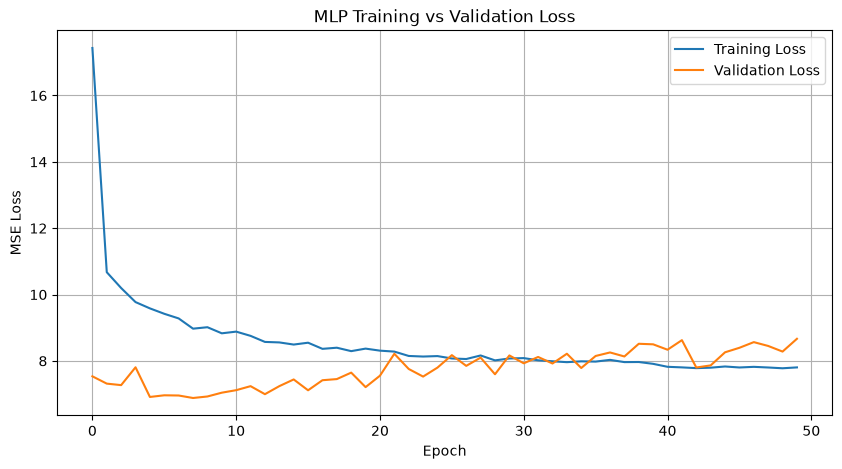

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MLP Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [80]:
best_epoch = np.argmin(history.history["val_loss"]) + 1
best_val_loss = min(history.history["val_loss"])
best_val_mae = min(history.history["val_mae"])

print("Best Epoch:", best_epoch)
print("Best Validation Loss:", round(best_val_loss, 4))
print("Best Validation MAE:", round(best_val_mae, 4))

Best Epoch: 8
Best Validation Loss: 6.882
Best Validation MAE: 1.7219


In [81]:
from tensorflow.keras.callbacks import EarlyStopping

# Create a fresh MLP model
mlp_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(1)
])

# Compile
mlp_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

# Train
history = mlp_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 18.3841 - mae: 2.8622 - val_loss: 8.5709 - val_mae: 1.9366
Epoch 2/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 11.0896 - mae: 2.2601 - val_loss: 7.8526 - val_mae: 1.8369
Epoch 3/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 10.3269 - mae: 2.1635 - val_loss: 7.8990 - val_mae: 1.8213
Epoch 4/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 10.0045 - mae: 2.1167 - val_loss: 7.0963 - val_mae: 1.8027
Epoch 5/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.5800 - mae: 2.0633 - val_loss: 7.8586 - val_mae: 1.8194
Epoch 6/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.3466 - mae: 2.0459 - val_loss: 7.5871 - val_mae: 1.8071
Epoch 7/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 9.3032 - mae: 2.0331 - val_loss: 7.7180 - val_mae: 1.8270
Epoch 8/50
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.0383 - mae: 2.0110 - val_loss: 8.3525 - val_mae: 1.8928
Epoch 9/50
1024/1024 ━━━━━━━━━━━━━━━

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions using the restored best model
y_pred_mlp = mlp_model.predict(X_test_scaled, verbose=0).flatten()

# Evaluation metrics
mlp_mae = mean_absolute_error(y_test, y_pred_mlp)
mlp_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mlp_r2 = r2_score(y_test, y_pred_mlp)

print("Final MLP Test Results")
print("----------------------")
print(f"MAE  : {mlp_mae:.4f}")
print(f"RMSE : {mlp_rmse:.4f}")
print(f"R²   : {mlp_r2:.4f}")

Final MLP Test Results
----------------------
MAE  : 2.5930
RMSE : 3.6788
R²   : 0.7595


In [83]:
mlp_results = {
    "Model": "MLP",
    "MAE": mlp_mae,
    "RMSE": mlp_rmse,
    "R2": mlp_r2
}

print(mlp_results)

{'Model': 'MLP', 'MAE': 2.5930399894714355, 'RMSE': np.float64(3.678825001964699), 'R2': 0.7595274448394775}


In [84]:
import numpy as np

# Sort by SKU and date
lstm_data = model_data.sort_values(
    ["sku_id", "date"]
).reset_index(drop=True)

# Features for the LSTM
lstm_features = [
    "units_sold",
    "unit_price",
    "promo_flag",
    "product_age_days",
    "day_of_week",
    "month",
    "is_weekend"
]

sequence_length = 30

X_lstm = []
y_lstm = []
dates_lstm = []
skus_lstm = []

# Create sequences separately for each SKU
for sku, group in lstm_data.groupby("sku_id"):
    
    group = group.sort_values("date").reset_index(drop=True)
    
    values = group[lstm_features].values
    targets = group["units_sold"].values
    dates = group["date"].values
    
    for i in range(sequence_length, len(group)):
        
        X_lstm.append(values[i-sequence_length:i])
        y_lstm.append(targets[i])
        dates_lstm.append(dates[i])
        skus_lstm.append(sku)

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)
dates_lstm = np.array(dates_lstm)
skus_lstm = np.array(skus_lstm)

print("LSTM sequence data created successfully!")
print("X_lstm shape:", X_lstm.shape)
print("y_lstm shape:", y_lstm.shape)

LSTM sequence data created successfully!
X_lstm shape: (48261, 30, 7)
y_lstm shape: (48261,)


In [85]:
# Use the same date boundary as the MLP
lstm_split_date = split_date

# Training sequences
train_mask_lstm = dates_lstm < lstm_split_date

# Testing sequences
test_mask_lstm = dates_lstm >= lstm_split_date

X_lstm_train = X_lstm[train_mask_lstm]
X_lstm_test = X_lstm[test_mask_lstm]

y_lstm_train = y_lstm[train_mask_lstm]
y_lstm_test = y_lstm[test_mask_lstm]

dates_lstm_train = dates_lstm[train_mask_lstm]
dates_lstm_test = dates_lstm[test_mask_lstm]

skus_lstm_train = skus_lstm[train_mask_lstm]
skus_lstm_test = skus_lstm[test_mask_lstm]

print("LSTM Train/Test Split")
print("--------------------")
print("X_lstm_train:", X_lstm_train.shape)
print("X_lstm_test :", X_lstm_test.shape)
print("y_lstm_train:", y_lstm_train.shape)
print("y_lstm_test :", y_lstm_test.shape)

print("\nTraining date range:",
      dates_lstm_train.min(), "to", dates_lstm_train.max())

print("Testing date range:",
      dates_lstm_test.min(), "to", dates_lstm_test.max())

print("\nDate overlap:",
      set(dates_lstm_train) & set(dates_lstm_test))

LSTM Train/Test Split
--------------------
X_lstm_train: (37961, 30, 7)
X_lstm_test : (10300, 30, 7)
y_lstm_train: (37961,)
y_lstm_test : (10300,)

Training date range: 2024-03-04T00:00:00.000000 to 2025-09-19T00:00:00.000000
Testing date range: 2025-09-20T00:00:00.000000 to 2025-12-31T00:00:00.000000

Date overlap: set()


In [86]:
from sklearn.preprocessing import StandardScaler

# Create scaler for LSTM features
lstm_scaler = StandardScaler()

# Reshape training data from 3D → 2D
n_train, timesteps, n_features = X_lstm_train.shape

X_lstm_train_2d = X_lstm_train.reshape(
    -1, n_features
)

# Fit scaler ONLY on training data
lstm_scaler.fit(X_lstm_train_2d)

# Scale training data
X_lstm_train_scaled = lstm_scaler.transform(
    X_lstm_train_2d
).reshape(n_train, timesteps, n_features)

# Scale test data using the training scaler
n_test = X_lstm_test.shape[0]

X_lstm_test_scaled = lstm_scaler.transform(
    X_lstm_test.reshape(-1, n_features)
).reshape(n_test, timesteps, n_features)

print("LSTM scaling completed successfully!")
print("X_lstm_train_scaled:", X_lstm_train_scaled.shape)
print("X_lstm_test_scaled :", X_lstm_test_scaled.shape)

LSTM scaling completed successfully!
X_lstm_train_scaled: (37961, 30, 7)
X_lstm_test_scaled : (10300, 30, 7)


In [87]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

lstm_model = Sequential([
    Input(shape=(X_lstm_train_scaled.shape[1],
                 X_lstm_train_scaled.shape[2])),

    LSTM(64, return_sequences=True),
    Dropout(0.20),

    LSTM(32),
    Dropout(0.20),

    Dense(16, activation="relu"),

    Dense(1)
])

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

print("LSTM model compiled successfully!")

LSTM model compiled successfully!


In [89]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_lstm = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    X_lstm_train_scaled,
    y_lstm_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_lstm],
    verbose=1
)

Epoch 1/50
949/949 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - loss: 17.3046 - mae: 2.6408 - val_loss: 10.2151 - val_mae: 2.1251
Epoch 2/50
949/949 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 9.2782 - mae: 2.0096 - val_loss: 10.0699 - val_mae: 2.0866
Epoch 3/50
949/949 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - loss: 8.9279 - mae: 1.9565 - val_loss: 9.6206 - val_mae: 2.0491
Epoch 4/50
949/949 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 8.7699 - mae: 1.9401 - val_loss: 9.4808 - val_mae: 2.0687
Epoch 5/50
949/949 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 8.5737 - mae: 1.9078 - val_loss: 9.5156 - val_mae: 2.0266
Epoch 6/50
949/949 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - loss: 8.3743 - mae: 1.8871 - val_loss: 9.3690 - val_mae: 2.0277
Epoch 7/50
949/949 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - loss: 8.3504 - mae: 1.8744 - val_loss: 9.7460 - val_mae: 2.0584
Epoch 8/50
949/949 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - loss: 8.3116 - mae: 1.8723 - val_loss: 9.7529 - val_mae: 2.0965
Epoch 9/50
949/949 ━━━━━━━━━━━━━━━━━━

In [90]:
y_pred_lstm = lstm_model.predict(
    X_lstm_test_scaled,
    verbose=0
).flatten()

print("LSTM predictions generated successfully!")
print("Number of predictions:", len(y_pred_lstm))
print("Actual test values:", len(y_lstm_test))


LSTM predictions generated successfully!
Number of predictions: 10300
Actual test values: 10300


In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lstm_mae = mean_absolute_error(y_lstm_test, y_pred_lstm)

lstm_rmse = np.sqrt(
    mean_squared_error(y_lstm_test, y_pred_lstm)
)

lstm_r2 = r2_score(
    y_lstm_test,
    y_pred_lstm
)

lstm_results = {
    "Model": "LSTM",
    "MAE": lstm_mae,
    "RMSE": lstm_rmse,
    "R2": lstm_r2
}

print(lstm_results)


{'Model': 'LSTM', 'MAE': 2.4356491565704346, 'RMSE': np.float64(3.6283955948732367), 'R2': 0.766075074672699}


In [92]:
import pandas as pd

model_comparison = pd.DataFrame([
    mlp_results,
    lstm_results
])

model_comparison["MAE"] = model_comparison["MAE"].round(4)
model_comparison["RMSE"] = model_comparison["RMSE"].round(4)
model_comparison["R2"] = model_comparison["R2"].round(4)

print(model_comparison)


  Model     MAE    RMSE      R2
0   MLP  2.5930  3.6788  0.7595
1  LSTM  2.4356  3.6284  0.7661


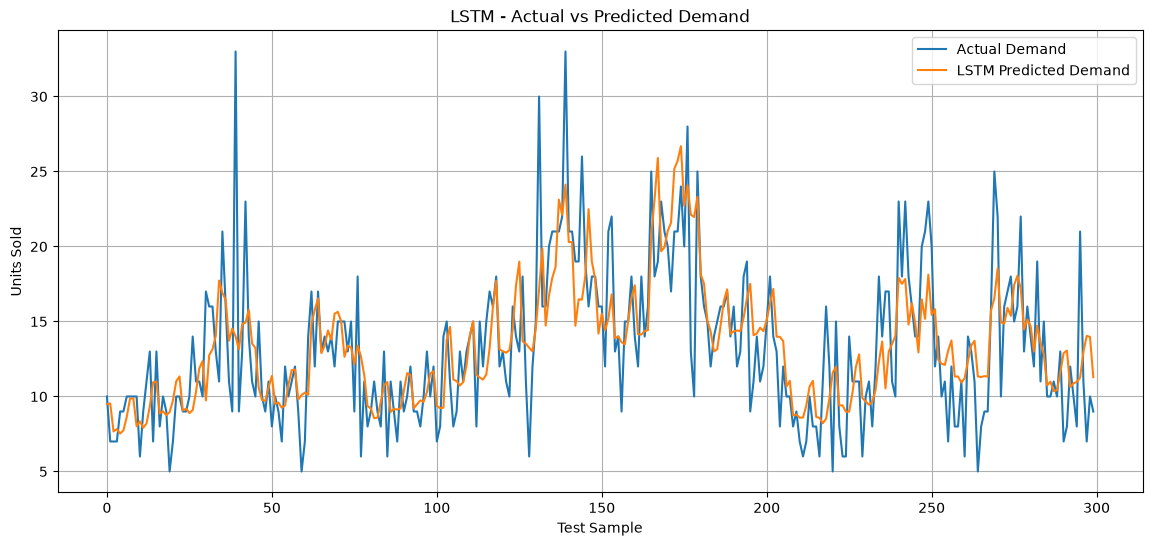

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    y_lstm_test[:300],
    label="Actual Demand"
)

plt.plot(
    y_pred_lstm[:300],
    label="LSTM Predicted Demand"
)

plt.title("LSTM - Actual vs Predicted Demand")
plt.xlabel("Test Sample")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)

plt.show()

In [94]:
actual = np.array(y_lstm_test)
predicted = np.array(y_pred_lstm)

percentage_error = (
    np.abs(actual - predicted) / np.maximum(actual, 1)
) * 100

accuracy_10 = np.mean(percentage_error <= 10) * 100
accuracy_20 = np.mean(percentage_error <= 20) * 100

print(f"Predictions within ±10% of actual demand: {accuracy_10:.2f}%")
print(f"Predictions within ±20% of actual demand: {accuracy_20:.2f}%")

Predictions within ±10% of actual demand: 33.28%
Predictions within ±20% of actual demand: 60.59%


In [95]:
evaluation_df = pd.DataFrame({
    "Actual": y_lstm_test,
    "Predicted": y_pred_lstm
})

evaluation_df["Absolute_Error"] = np.abs(
    evaluation_df["Actual"] - evaluation_df["Predicted"]
)

evaluation_df["Error_Percentage"] = (
    evaluation_df["Absolute_Error"] /
    np.maximum(evaluation_df["Actual"], 1)
) * 100

evaluation_df["Demand_Level"] = pd.cut(
    evaluation_df["Actual"],
    bins=[0, 5, 10, 20, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

demand_performance = evaluation_df.groupby(
    "Demand_Level",
    observed=False
).agg(
    Samples=("Actual", "count"),
    MAE=("Absolute_Error", "mean"),
    Average_Actual=("Actual", "mean"),
    Average_Predicted=("Predicted", "mean")
).reset_index()

demand_performance["MAE"] = demand_performance["MAE"].round(3)
demand_performance["Average_Actual"] = demand_performance["Average_Actual"].round(2)
demand_performance["Average_Predicted"] = demand_performance["Average_Predicted"].round(2)

print(demand_performance)

  Demand_Level  Samples    MAE  Average_Actual  Average_Predicted
0          Low     1470  1.266            4.09           5.150000
1       Medium     3441  1.693            7.97           8.910000
2         High     3986  2.467           14.67          14.900000
3    Very High     1403  5.396           26.99          23.370001


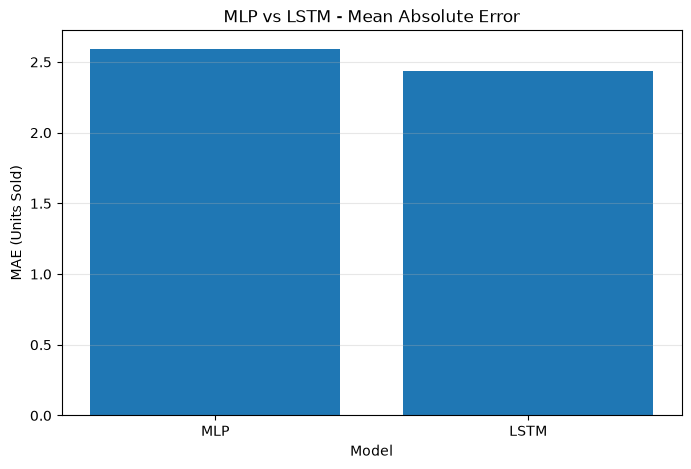

In [96]:
import matplotlib.pyplot as plt

models = model_comparison["Model"]
mae_values = model_comparison["MAE"]

plt.figure(figsize=(8, 5))

plt.bar(models, mae_values)

plt.title("MLP vs LSTM - Mean Absolute Error")
plt.xlabel("Model")
plt.ylabel("MAE (Units Sold)")
plt.grid(axis="y", alpha=0.3)

plt.show()

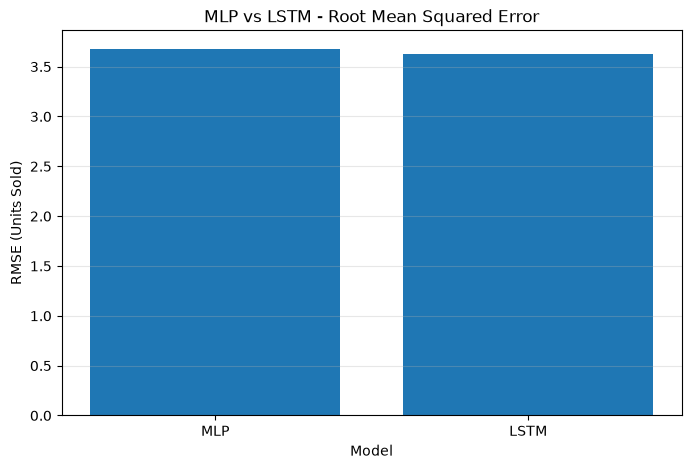

In [97]:
models = model_comparison["Model"]
rmse_values = model_comparison["RMSE"]

plt.figure(figsize=(8, 5))

plt.bar(models, rmse_values)

plt.title("MLP vs LSTM - Root Mean Squared Error")
plt.xlabel("Model")
plt.ylabel("RMSE (Units Sold)")
plt.grid(axis="y", alpha=0.3)

plt.show()

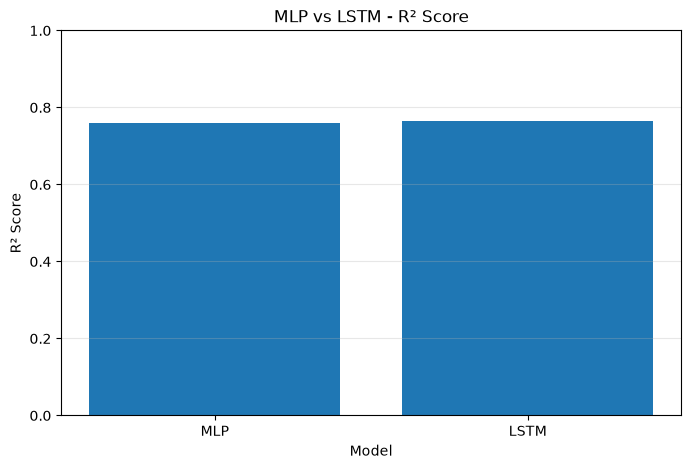

In [98]:
r2_values = model_comparison["R2"]

plt.figure(figsize=(8, 5))

plt.bar(models, r2_values)

plt.title("MLP vs LSTM - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.show()


In [99]:
import os

os.makedirs("models", exist_ok=True)

mlp_model.save("models/mlp_demand_model.keras")
lstm_model.save("models/lstm_demand_model.keras")

print("Models saved successfully!")
print("MLP model  : models/mlp_demand_model.keras")
print("LSTM model : models/lstm_demand_model.keras")

Models saved successfully!
MLP model  : models/mlp_demand_model.keras
LSTM model : models/lstm_demand_model.keras


In [100]:
import joblib

joblib.dump(
    scaler,
    "models/mlp_scaler.pkl"
)

joblib.dump(
    lstm_scaler,
    "models/lstm_scaler.pkl"
)

print("Scalers saved successfully!")
print("MLP scaler  : models/mlp_scaler.pkl")
print("LSTM scaler : models/lstm_scaler.pkl")


Scalers saved successfully!
MLP scaler  : models/mlp_scaler.pkl
LSTM scaler : models/lstm_scaler.pkl


In [101]:
model_comparison.to_csv(
    "models/model_comparison.csv",
    index=False
)

print("Model comparison results saved successfully!")
print(model_comparison)


Model comparison results saved successfully!
  Model     MAE    RMSE      R2
0   MLP  2.5930  3.6788  0.7595
1  LSTM  2.4356  3.6284  0.7661


In [102]:
lstm_predictions_df = pd.DataFrame({
    "date": dates_lstm_test,
    "sku_id": skus_lstm_test,
    "actual_units": y_lstm_test,
    "predicted_units": y_pred_lstm
})

lstm_predictions_df["absolute_error"] = np.abs(
    lstm_predictions_df["actual_units"] -
    lstm_predictions_df["predicted_units"]
)

lstm_predictions_df.to_csv(
    "models/lstm_predictions.csv",
    index=False
)

print("LSTM predictions saved successfully!")
print("Rows saved:", len(lstm_predictions_df))
print(lstm_predictions_df.head())


LSTM predictions saved successfully!
Rows saved: 10300
        date  sku_id  actual_units  predicted_units  absolute_error
0 2025-09-20  SKU001            10         9.498437        0.501563
1 2025-09-21  SKU001             7         9.531569        2.531569
2 2025-09-22  SKU001             7         7.668403        0.668403
3 2025-09-23  SKU001             7         7.831088        0.831088
4 2025-09-24  SKU001             9         7.532829        1.467171


In [103]:
def predict_lstm_demand(sku_data):
    """
    Predict next-day demand using the trained LSTM model.

    sku_data must contain the latest 30 days of:
    units_sold, unit_price, promo_flag,
    product_age_days, day_of_week, month, is_weekend
    """

    required_columns = [
        "units_sold",
        "unit_price",
        "promo_flag",
        "product_age_days",
        "day_of_week",
        "month",
        "is_weekend"
    ]

    if len(sku_data) < 30:
        raise ValueError("At least 30 days of data are required.")

    sequence = sku_data[required_columns].tail(30).values

    sequence_scaled = lstm_scaler.transform(sequence)

    sequence_scaled = sequence_scaled.reshape(
        1, 30, len(required_columns)
    )

    prediction = lstm_model.predict(
        sequence_scaled,
        verbose=0
    )[0][0]

    return max(0, prediction)


print("LSTM prediction function created successfully!")

LSTM prediction function created successfully!


In [104]:
test_sku = "SKU001"

sku_test_data = (
    model_data[model_data["sku_id"] == test_sku]
    .sort_values("date")
    .tail(30)
    .copy()
)

predicted_demand = predict_lstm_demand(sku_test_data)

print("SKU:", test_sku)
print("Latest date:", sku_test_data["date"].max())
print(f"Predicted next-day demand: {predicted_demand:.2f} units")


SKU: SKU001
Latest date: 2025-12-31 00:00:00
Predicted next-day demand: 9.63 units


In [105]:
predicted_units = round(predicted_demand)

if predicted_units <= 5:
    demand_category = "Low"
elif predicted_units <= 10:
    demand_category = "Medium"
elif predicted_units <= 20:
    demand_category = "High"
else:
    demand_category = "Very High"

prediction_summary = {
    "SKU": test_sku,
    "Last Available Date": sku_test_data["date"].max().strftime("%Y-%m-%d"),
    "Forecast Date": (
        sku_test_data["date"].max() +
        pd.Timedelta(days=1)
    ).strftime("%Y-%m-%d"),
    "Predicted Demand": predicted_units,
    "Demand Category": demand_category
}

print("Prediction Summary")
print("------------------")

for key, value in prediction_summary.items():
    print(f"{key}: {value}")
    

Prediction Summary
------------------
SKU: SKU001
Last Available Date: 2025-12-31
Forecast Date: 2026-01-01
Predicted Demand: 10
Demand Category: Medium


In [106]:
import os

model_path = os.path.join(
    "models",
    "lstm_demand_model.keras"
)

print("Model path:")
print(os.path.abspath(model_path))

print("\nFile exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("File size:", os.path.getsize(model_path), "bytes")

Model path:
c:\Users\allan\OneDrive\Desktop\foresight\notebooks\models\lstm_demand_model.keras

File exists: True
File size: 418765 bytes


In [107]:
import os

root_model_path = os.path.abspath(
    os.path.join(
        "..",
        "models",
        "lstm_demand_model.keras"
    )
)

print("Root model path:")
print(root_model_path)

print("\nFile exists:", os.path.exists(root_model_path))

if os.path.exists(root_model_path):
    print("File size:", os.path.getsize(root_model_path), "bytes")

Root model path:
c:\Users\allan\OneDrive\Desktop\foresight\models\lstm_demand_model.keras

File exists: False


In [108]:
import os
from tensorflow.keras.models import load_model

model_path = os.path.abspath(
    os.path.join("..", "models", "lstm_demand_model.keras")
)

print("Loading model from:")
print(model_path)

test_model = load_model(model_path)

print("\nLSTM model loaded successfully!")
print("Input shape:", test_model.input_shape)
print("Output shape:", test_model.output_shape)

Loading model from:
c:\Users\allan\OneDrive\Desktop\foresight\models\lstm_demand_model.keras

LSTM model loaded successfully!
Input shape: (None, 30, 7)
Output shape: (None, 1)


In [110]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root:")
print(project_root)

print("\nutils folder exists:")
print(os.path.exists(os.path.join(project_root, "utils")))

Project root:
c:\Users\allan\OneDrive\Desktop\foresight

utils folder exists:
True


In [111]:
from utils.lstm_predictor import (
    predict_lstm_demand,
    get_demand_category
)

print("LSTM predictor imported successfully!")

LSTM predictor imported successfully!


In [112]:
from utils.lstm_predictor import (
    predict_lstm_demand,
    get_demand_category
)

test_sku = "SKU001"

sku_test_data = (
    model_data[
        model_data["sku_id"] == test_sku
    ]
    .sort_values("date")
    .tail(30)
    .copy()
)

predicted_demand = predict_lstm_demand(sku_test_data)

demand_category = get_demand_category(
    predicted_demand
)

print("SKU:", test_sku)
print("Latest date:", sku_test_data["date"].max())
print(f"Predicted next-day demand: {predicted_demand:.2f} units")
print("Demand category:", demand_category)

SKU: SKU001
Latest date: 2025-12-31 00:00:00
Predicted next-day demand: 9.63 units
Demand category: Medium


In [113]:
import os

os.makedirs("../data", exist_ok=True)

model_data.to_csv(
    "../data/model_data.csv",
    index=False
)

print("Model data saved successfully!")
print("Rows:", len(model_data))
print("Columns:", len(model_data.columns))

Model data saved successfully!
Rows: 51261
Columns: 31
